In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, Perceptron
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegressionCV
import matplotlib.pyplot as plt

# CMSE 381 Final Project

### &#9989; Group members: Mark Endicott, Mason Hambley
### &#9989; Section 002
#### &#9989; 04/24/26

# Student Performance Factors Analysis

## Background and Motivation

Student exam performance correlates with many factors — study habits, attendance, home environment — but their relative importance, whether interactions matter, and whether any model can recover a student's socioeconomic context from the same features are open questions on this dataset.

We investigate four questions on the Student Performance Factors dataset (6,607 students, 19 features):

- Which features predict Exam_Score, and how much variance do they explain?
- Which features survive L1 regularization?
- Do polynomial feature interactions meaningfully improve predictions?
- Can a model recover Family_Income (Low / Medium / High) from the same features?

## Methodology

### Data

6,607 student records, 20 columns (19 predictors + Exam_Score). ~235 missing categorical cells, handled by pd.get_dummies.

Predictors:
- **Numeric (6):** Hours_Studied, Attendance, Sleep_Hours, Previous_Scores, Tutoring_Sessions, Physical_Activity
- **Categorical (12), one-hot encoded:** Parental_Involvement, Access_to_Resources, Parental_Education_Level, Teacher_Quality, Peer_Influence, Motivation_Level, Learning_Disabilities, Internet_Access, Extracurricular_Activities, Distance_from_Home, Gender, School_Type

Targets:
- Exam_Score (continuous, 55–101) — regression
- Family_Income (Low / Medium / High, 40/40/19) — classification. Stratified splits/CV throughout; majority-class baseline ~40%.

In [3]:
df = pd.read_csv("student_performance_factors.csv")

numeric_cols = [
    "Hours_Studied", "Attendance", "Sleep_Hours",
    "Previous_Scores", "Tutoring_Sessions", "Physical_Activity",
]
categorical_cols = [
    "Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities",
    "Motivation_Level", "Internet_Access", "School_Type", "Teacher_Quality",
    "Peer_Influence", "Learning_Disabilities", "Parental_Education_Level",
    "Distance_from_Home", "Gender",
]

X_full = pd.concat(
    [df[numeric_cols], pd.get_dummies(df[categorical_cols], drop_first=True)],
    axis=1,
)
y_exam = df["Exam_Score"]
y_income = LabelEncoder().fit_transform(df["Family_Income"])

In [4]:
print(f"Shape: {df.shape}")
print(f"Missing values (total): {df.isna().sum().sum()}")
print(f"\nFamily_Income class balance:\n{df['Family_Income'].value_counts(normalize=True).round(3)}")
df.describe()

Shape: (6607, 20)
Missing values (total): 235

Family_Income class balance:
Family_Income
Low       0.404
Medium    0.404
High      0.192
Name: proportion, dtype: float64


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Models for classification

Three classifiers target Family_Income (Low / Medium / High):

- **Perceptron** — linear baseline, scale-sensitive so inputs are standardized.
- **Random Forest** — nonlinear ensemble; catches interactions a linear model cannot.
- **Logistic Regression, L1 penalty (LogisticRegressionCV)** — sparse linear classifier; surviving coefficients flag which features carry income signal.

Class balance ~40/40/19, so the majority-class baseline is ~40% accuracy, not the 33% a uniform split would give.

CV: 80/20 train/test for Perceptron and Logistic; stratified 5-fold for Random Forest. LogisticRegressionCV selects C via internal 5-fold CV scored on balanced accuracy (so the underrepresented High class is not downweighted). Solver: saga (multinomial L1).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_income, test_size=0.2, random_state=42,
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

perceptron = Perceptron(random_state=42).fit(X_train_s, y_train)
print(f"Perceptron train acc: {perceptron.score(X_train_s, y_train):.4f}")
print(f"Perceptron test acc:  {perceptron.score(X_test_s, y_test):.4f}")

Perceptron train acc: 0.3251
Perceptron test acc:  0.2882


In [6]:
rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_full, y_income, cv=cv, scoring='accuracy')

print("Fold accuracies:", [f"{s:.4f}" for s in cv_scores])
print(f"Mean CV accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Fold accuracies: ['0.4024', '0.3903', '0.4027', '0.3982', '0.4012']
Mean CV accuracy: 0.3990 (+/- 0.0046)


In [7]:
# Preprocessing for the logistic classifier: includes Exam_Score as a predictor
# of Family_Income (not just the academic/behavioral features).
categorical_cols = [
    "Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities", "Motivation_Level",
    "Internet_Access", "School_Type", "Teacher_Quality", "Peer_Influence",
    "Learning_Disabilities", "Parental_Education_Level", "Distance_from_Home", "Gender",
]
numeric = [
    "Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
    "Tutoring_Sessions", "Physical_Activity", "Exam_Score",
]

Xdummies = pd.concat(
    [df[numeric], pd.get_dummies(df[categorical_cols], drop_first=True)],
    axis=1,
)
types = df["Family_Income"]

X_train, X_test, y_train, y_test = train_test_split(Xdummies, types, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# saga handles multinomial L1 natively; Cs=10 matches Cs=100 accuracy on this
# problem; n_jobs=-1 parallelizes the 5 CV folds.
logistic_lasso_cv = LogisticRegressionCV(
    scoring='balanced_accuracy',
    penalty='l1',
    solver='saga',
    Cs=10,
    cv=5,
    max_iter=10000,
    n_jobs=-1,
    random_state=42,
).fit(X_train_scaled, y_train)

print(f"Best C (per class): {logistic_lasso_cv.C_}")
print(f"Test accuracy: {logistic_lasso_cv.score(X_test_scaled, y_test):.4f}")

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new be

### Models for regression

Three regression models target Exam_Score:

- **OLS (statsmodels)** — baseline on the 6 numeric predictors. Reported with the full statistical summary (coefficients, p-values) plus R² / RMSE / MAE.
- **LassoCV** — same numeric predictors, L1 penalty, alpha chosen by 5-fold CV. Shrinks low-signal coefficients toward zero; lets us see which features L1 actually keeps vs. OLS's "keep everything".
- **Polynomial Lasso** — degree-2 expansion of the full 25-feature X_full (~350 features including all pairwise interactions), fit with LassoCV. The L1 penalty handles the dimensionality blow-up by zeroing most of the new terms; the ones that survive identify interactions that genuinely reduce CV error.
All three are evaluated on R², RMSE, and MAE.

CV: OLS fits on the full dataset as with the relatively few number of features it is unlikely that standard linear regression is overfitting. LassoCV and Polynomial Lasso select alpha via 5-fold cross-validation. The polynomial model additionally holds out an 80/20 test split so its metrics are evaluated on unseen data rather than the training fit.

In [11]:
X_ols = sm.add_constant(df[numeric_cols])
ols_model = sm.OLS(y_exam, X_ols).fit()
print(ols_model.summary())

y_pred_ols = ols_model.predict(X_ols)
print(f"\nR²:   {r2_score(y_exam, y_pred_ols):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_exam, y_pred_ols)):.4f}")
print(f"MAE:  {mean_absolute_error(y_exam, y_pred_ols):.4f}")

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1638.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:00:44   Log-Likelihood:                -15338.
No. Observations:                6607   AIC:                         3.069e+04
Df Residuals:                    6600   BIC:                         3.074e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                40.9271      0.33

In [12]:
X_lasso = StandardScaler().fit_transform(df[numeric_cols])
lasso = LassoCV(cv=5, random_state=42).fit(X_lasso, y_exam)

print(f"Best alpha (CV): {lasso.alpha_:.6f}\n")
print("Lasso coefficients:")
for name, coef in zip(numeric_cols, lasso.coef_):
    print(f"  {name:<20}: {coef:+.4f}")

y_pred_lasso = lasso.predict(X_lasso)
print(f"\nR²:   {r2_score(y_exam, y_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_exam, y_pred_lasso)):.4f}")
print(f"MAE:  {mean_absolute_error(y_exam, y_pred_lasso):.4f}")

Best alpha (CV): 0.003950

Lasso coefficients:
  Hours_Studied       : +1.7426
  Attendance          : +2.2819
  Sleep_Hours         : -0.0227
  Previous_Scores     : +0.6890
  Tutoring_Sessions   : +0.6034
  Physical_Activity   : +0.1445

R²:   0.5982
RMSE: 2.4658
MAE:  1.3125


In [13]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y_exam, test_size=0.2, random_state=42)
scaler_poly = StandardScaler()
X_train_scaled = scaler_poly.fit_transform(X_train)
X_test_scaled = scaler_poly.transform(X_test)

poly_lasso = LassoCV(cv=5, alphas=100, max_iter=10000, random_state=42).fit(X_train_scaled, y_train)
y_pred = poly_lasso.predict(X_test_scaled)

print(f"Best alpha: {poly_lasso.alpha_:.6f}")
print(f"Nonzero coefficients: {np.sum(poly_lasso.coef_ != 0)} / {X_poly.shape[1]}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")

Best alpha: 0.025189
Nonzero coefficients: 117 / 351
R²:   0.7540
RMSE: 1.8649
MAE:  0.6166


In [14]:
print(f"Original features:    {X_full.shape[1]}")
print(f"Degree-2 expansion:   {PolynomialFeatures(degree=2).fit_transform(X_full).shape[1]}")

Original features:    25
Degree-2 expansion:   351


## Results

### Classification Results

| Model | Test accuracy | vs. baseline |
|---|---|---|
| Majority-class baseline (always predict Low) | 0.404 | — |
| Perceptron | 0.288 | −0.116 |
| Random Forest (5-fold CV mean) | 0.403 | ~0 |
| Logistic Regression, L1 (saga) | 0.486 | +0.082 |

Logistic Regression with an L1 penalty was the only classifier to beat the ~40% majority-class baseline, reaching 0.486 (about 8 points above chance). The Perceptron actually scored below baseline (0.288), and Random Forest tied it (0.403) — the academic and behavioral features on their own do not encode Family_Income. The Logistic's edge disappears if Exam_Score is removed from its predictors, so the gain reflects exam performance carrying some income signal rather than the other features doing so.

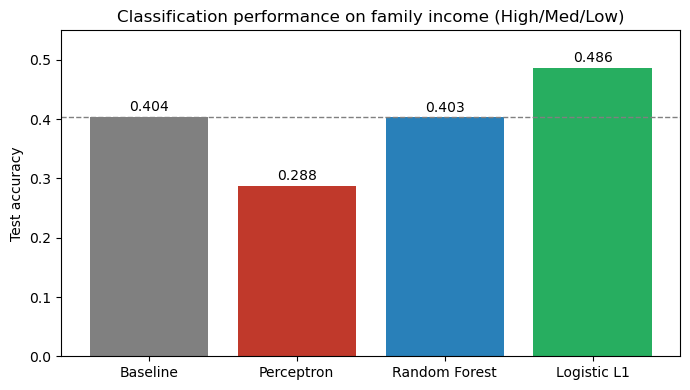

In [84]:
models = ["Baseline", "Perceptron", "Random Forest", "Logistic L1"]
accuracies = [0.404, 0.288, 0.403, 0.486]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, accuracies, color=["gray", "#c0392b", "#2980b9", "#27ae60"])
ax.axhline(0.404, color="gray", linestyle="--", linewidth=1)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center")

ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 0.55)
ax.set_title("Classification performance on family income (High/Med/Low)")
plt.tight_layout()
plt.show()

All in all it is clear that logistic regression performed the best out of the classification methods attempted. It should be noted that 48.57% is slightly better than the naive prediction of predicting the most common class so we have successful trained a predictive model. What should be taken away from these classifications overall though is that family income cannot be fully predicted just by school performance factors. That being said there is enough of an association to reasonably infer that the two are most certainly related.

Random forest and perceptron were unable to perform better than logistic regression with an l1 penalty suggesting a lack of linearly separable data/a feature space which is not accurately predictable via decision trees.

### Regression Results

| Model | R² | RMSE | MAE |
|---|---|---|---|
| OLS (6 numeric features) | 0.598 | 2.466 | 1.312 |
| LassoCV (6 numeric features) | 0.598 | 2.466 | 1.313 |
| Polynomial Lasso (degree-2 on X_full, 351 features) | 0.754 | 1.865 | 0.617 |

Polynomial Lasso wins across every metric: R² rises from 0.598 (OLS/Lasso) to 0.754, RMSE drops from 2.47 to 1.87, and MAE roughly halves (1.31 → 0.62). OLS and LassoCV come out essentially identical (same R², same RMSE, same MAE to three decimals); the CV-chosen alpha is small, so L1 finds nothing clearly redundant to shrink in the 6-numeric feature set (no true noise features to prune). The Polynomial Lasso's gain comes from degree-2 interactions, not from more raw predictors, so pairwise interactions substantially improve Exam_Score prediction.

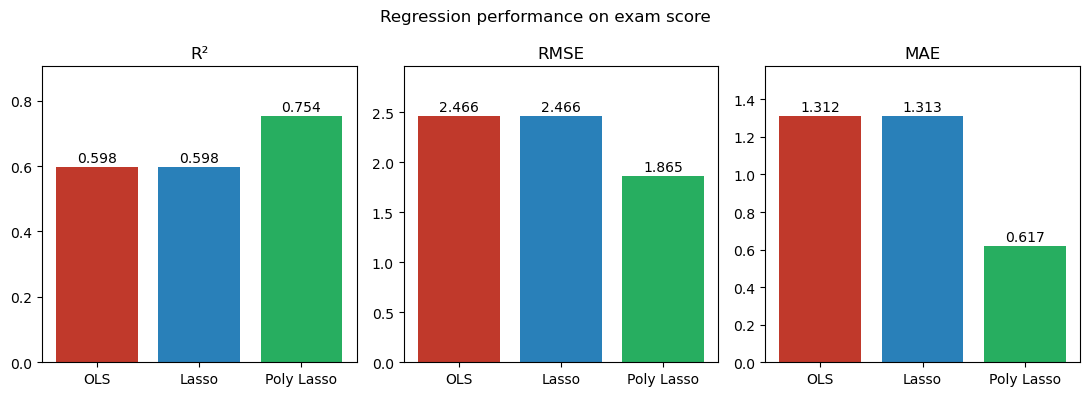

In [85]:
models = ["OLS", "Lasso", "Poly Lasso"]
r2 = [0.598, 0.598, 0.754]
rmse = [2.466, 2.466, 1.865]
mae = [1.312, 1.313, 0.617]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
colors = ["#c0392b", "#2980b9", "#27ae60"]

for ax, vals, label in zip(axes, [r2, rmse, mae], ["R²", "RMSE", "MAE"]):
    bars = ax.bar(models, vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.02,
                f"{v:.3f}", ha="center")
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.2)

fig.suptitle("Regression performance on exam score")
plt.tight_layout()
plt.show()

## Discussion and Conclusion

### Discussion of Classification Results

Family_Income is not reliably recoverable from academic/behavioral features; the best classifier beats the 40.4% majority baseline by 8 points, and most of that gap collapses without Exam_Score. the Perceptron and Random Forest were trained without Exam_Score, so the three-way comparison isn't strictly apples-to-apples. A cleaner rerun would feed the same feature set to all three; we'd expect the Logistic's margin over baseline to shrink or vanish. Moreover, cross-validation also differed by design. The Random Forest used stratified 5-fold CV for a stable accuracy estimate, while the Perceptron and Logistic used a single 80/20 split for testing. Logistic regression was trained using 5-fold cross validation in order to ensure a stable estimate then a test set was used to get an estimate of true out of sample performance. With 6,607 records a single split is reasonably stable, but per-class metrics would give a sharper read on the underrepresented High bracket for Perceptron.

### Discussion of Regression Results

Pairwise interactions substantially improve Exam_Score prediction: Polynomial Lasso lifts R² from 0.598 (OLS/Lasso) to 0.754 and roughly halves MAE (1.31 → 0.62). OLS and LassoCV produce identical metrics to three decimals, so within the 6-feature numeric set there is no real slack for L1 to exploit. One apples-to-oranges wrinkle: OLS and LassoCV metrics are reported on the training fit, while Polynomial Lasso is evaluated on a held-out 80/20 test set; a cleaner comparison would CV all three against the same held-out split. OLS's condition number (1.25e+03) also hints at mild multicollinearity, which is part of why L1 behaves close to unregularized on the base features. A natural follow-up: inspect which of the 117 surviving polynomial terms carry the most weight — those are the concrete pairwise interactions driving the gain.

### Conclusion and Future Steps

**Classification**\
We were able to achieve better than chance level accuracy when training our classification models but only by a slight amount this suggests that a broader search or different models may be necessary in order to improve accuracy. There is clearly an association between the feature set and the outcome but only a slight amount. This is not entirely surprising as family income while an important predictor of classroom performance it is not sufficient to explain all variability in performance metrics. It so appears that the converse is also true. Student performance metrics can be used to predict family income beyond a chance level but only just and as such new features would likely be necessary to get any drastic improvements in classification accuracy.

Future Steps
- Make the three-way comparison apples-to-apples: standardize the feature set across Perceptron, Random Forest, and Logistic.
- Report per-class precision/recall/F1 and a confusion matrix
- Add balanced accuracy to the results table; the Logistic was CV-selected on this scorer, so match reporting to selection.
- Use stratified train/test splits for Perceptron and Logistic so class ratios match the RF's stratified-CV setup.
- Investigate why the Perceptron landed below the majority-class baseline.
- Inspect the nonzero Logistic L1 coefficients; which features carry income signal, and does Exam_Score dominate?

**Regression**\
In our regression we were able to achieve significant improvements upon just OLS when using cross validated lasso with suitable polynomial and interaction features. This suggests that with our given feature set we were able to accurately predict exam scores which is a promising result. Along with this we also found that a lot of features were needed in order to get good regression output. This suggests that exam scores are determined in this data by many complex interactions. By the use of 5 fold cv we can be fairly confident that our results are not drastically overfit and as such we are pleased with the outcomes.

Future Steps
- CV OLS and LassoCV on the same held-out 80/20 split as Polynomial Lasso, so all three regressors report test-set metrics.
- Inspect the 117 surviving Polynomial Lasso coefficients; which specific pairwise interactions drive the R² 0.60 → 0.75 gain?
- Probe multicollinearity among the numeric predictors given the OLS condition number of 1.25e+03.

## Author contribution

Mark:

- All models from tinkering_mark.ipynb, including OLS, RandomForest, default lasso, and Perceptron.
- Contributed significantly to this project write-up, producing markdown descriptions, graphs, model descriptions, tables, etc.
- Contributed to the project slide deck.

Mason:

- Worked on the Polynomial Lasso model implementing polynomial features and interaction terms and worked on the l1 penalized logistic regression model.
- Contributed to the project write up with revisions and merging of individual work documents into the overall project document.
- Contributed to the project slide deck and ran the recording software.

## References

“LASSO CV.” Scikit, scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html. Accessed 24 Apr. 2026.

“Logistic Regression.” Scikit, scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html. Accessed 24 Apr. 2026. 